In [ ]:
import pandas as pd
import os

possible_paths = [
    '../data/raw/data/',  
    'data/raw/data/',     
    './data/raw/data/'
]

stock_data_path = None
for p in possible_paths:
    if os.path.exists(p):
        stock_data_path = p
        print(f"✅ Found data directory at: {p}")
        break

if not stock_data_path:
    print(f"❌ ERROR: Could not find the folder. Current working directory is: {os.getcwd()}")
else:
    def prepare_stock_data(directory):
        stocks_dict = {}
        
        files = [f for f in os.listdir(directory) if f.endswith('.csv')]
        print(f"📂 Found {len(files)} CSV files in {directory}...\n")
        
        for filename in files:
            ticker = filename.split('_')[0].upper()
            file_path = os.path.join(directory, filename)
            
            df = pd.read_csv(file_path)
            
            df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
            
            if 'Date' in df.columns:
                df['Date'] = pd.to_datetime(df['Date'], utc=True, errors='coerce')
                df.set_index('Date', inplace=True)
            
            if not isinstance(df.index, pd.DatetimeIndex):
                df.index = pd.to_datetime(df.index, utc=True, errors='coerce')

            df = df[df.index.notna()]
            
            cols = ['Open', 'High', 'Low', 'Close', 'Volume']
            for col in cols:
                if col in df.columns:
                    df[col] = pd.to_numeric(df[col], errors='coerce')
            
            df = df.sort_index()
            if isinstance(df.index, pd.DatetimeIndex) and df.isnull().values.any():
                df = df.interpolate(method='time').ffill().bfill()
            elif df.isnull().values.any():
                df = df.interpolate(method='linear').ffill().bfill()
            
            stocks_dict[ticker] = df
            print(f"📊 {ticker}: Cleaned and Indexed ({len(df)} rows).")
                
        return stocks_dict

    stocks_dict = prepare_stock_data(stock_data_path)
    
    if stocks_dict:
        test_ticker = list(stocks_dict.keys())[0]
        test_df = stocks_dict[test_ticker]
        print(f"\n--- 📋 Audit Report: {test_ticker} ---")
        print(f"Missing Values: {test_df.isnull().sum().sum()}")
        print(f"Index Type: {type(test_df.index)}")

✅ Found data directory at: ../data/raw/data/
📂 Found 5 CSV files in ../data/raw/data/...

📊 AAPL.CSV: Cleaned and Indexed (3774 rows).
📊 AMZN.CSV: Cleaned and Indexed (3774 rows).
📊 GOOG.CSV: Cleaned and Indexed (3774 rows).
📊 META.CSV: Cleaned and Indexed (2923 rows).
📊 NVDA.CSV: Cleaned and Indexed (3774 rows).

--- 📋 Audit Report: AAPL.CSV ---
Missing Values: 0
Index Type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>


✅ Found data directory at: ../data/raw/data/
📂 Found 5 CSV files in ../data/raw/data/...

--- Computing Technical Indicators ---
✅ Indicators computed for AAPL.CSV
✅ Indicators computed for AMZN.CSV
✅ Indicators computed for GOOG.CSV
✅ Indicators computed for META.CSV
✅ Indicators computed for NVDA.CSV

--- Generating Professional Dashboard ---


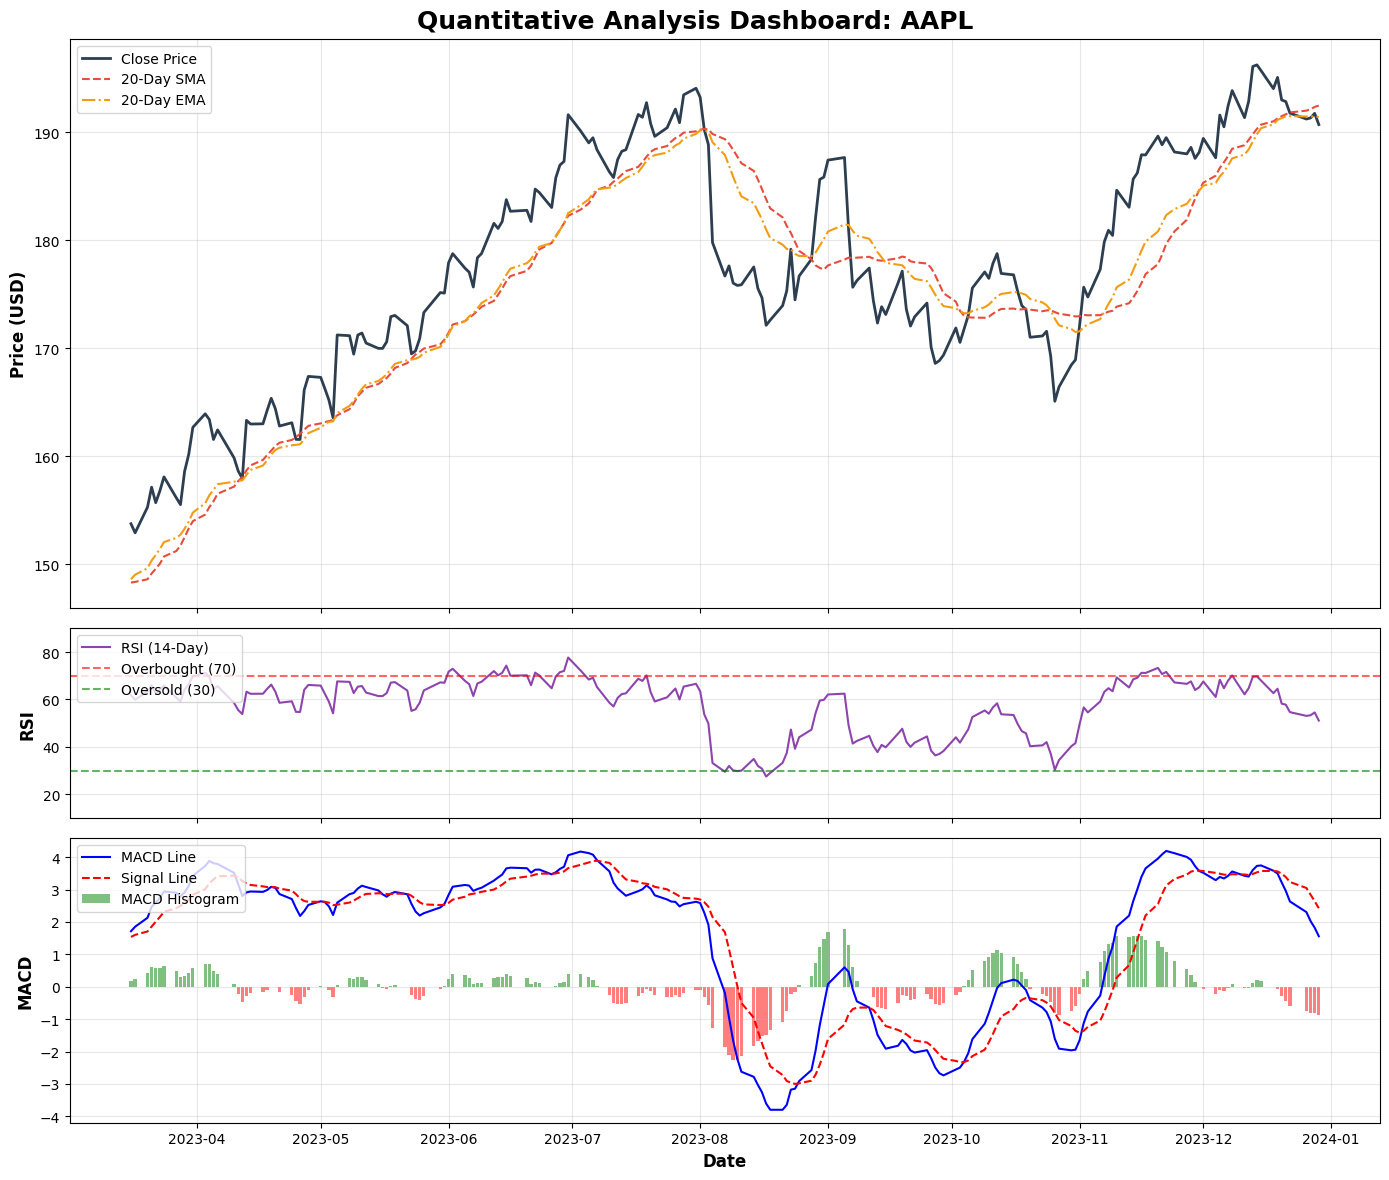

In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt

# ==========================================
# PART 1: DATA PREPARATION & LOADING
# ==========================================
possible_paths = ['../data/raw/data/', 'data/raw/data/', './data/raw/data/']
stock_data_path = None
for p in possible_paths:
    if os.path.exists(p):
        stock_data_path = p
        print(f"✅ Found data directory at: {p}")
        break

if not stock_data_path:
    print(f"❌ ERROR: Could not find the folder. Current working directory is: {os.getcwd()}")
else:
    def prepare_stock_data(directory):
        stocks_dict = {}
        files = [f for f in os.listdir(directory) if f.endswith('.csv')]
        print(f"📂 Found {len(files)} CSV files in {directory}...\n")
        
        for filename in files:
            ticker = filename.split('_')[0].upper()
            file_path = os.path.join(directory, filename)
            
            df = pd.read_csv(file_path)
            df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
            
            if 'Date' in df.columns:
                df['Date'] = pd.to_datetime(df['Date'], utc=True, errors='coerce')
                df.set_index('Date', inplace=True)
            
            if not isinstance(df.index, pd.DatetimeIndex):
                df.index = pd.to_datetime(df.index, utc=True, errors='coerce')

            df = df[df.index.notna()]
            cols = ['Open', 'High', 'Low', 'Close', 'Volume']
            for col in cols:
                if col in df.columns:
                    df[col] = pd.to_numeric(df[col], errors='coerce')
            
            df = df.sort_index()
            if isinstance(df.index, pd.DatetimeIndex) and df.isnull().values.any():
                df = df.interpolate(method='time').ffill().bfill()
            elif df.isnull().values.any():
                df = df.interpolate(method='linear').ffill().bfill()
            
            stocks_dict[ticker] = df
                
        return stocks_dict

    stocks_dict = prepare_stock_data(stock_data_path)

    # ==========================================
    # PART 2: COMPUTE TECHNICAL INDICATORS (Pure Pandas)
    # ==========================================
    def apply_technical_indicators(stocks_dict):
        print("--- Computing Technical Indicators ---")
        for ticker, df in stocks_dict.items():
            # 1. Moving Averages
            df['SMA_20'] = df['Close'].rolling(window=20).mean()
            df['SMA_50'] = df['Close'].rolling(window=50).mean()
            df['EMA_20'] = df['Close'].ewm(span=20, adjust=False).mean()
            
            # 2. RSI (14-day)
            delta = df['Close'].diff()
            gain = delta.where(delta > 0, 0)
            loss = -delta.where(delta < 0, 0)
            avg_gain = gain.ewm(alpha=1/14, adjust=False).mean()
            avg_loss = loss.ewm(alpha=1/14, adjust=False).mean()
            rs = avg_gain / avg_loss
            df['RSI_14'] = 100 - (100 / (1 + rs))
            
            # 3. MACD
            ema_12 = df['Close'].ewm(span=12, adjust=False).mean()
            ema_26 = df['Close'].ewm(span=26, adjust=False).mean()
            df['MACD'] = ema_12 - ema_26
            df['MACD_signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
            df['MACD_hist'] = df['MACD'] - df['MACD_signal']
            
            # 4. Daily Returns
            df['Daily_Return'] = df['Close'].pct_change()
            
            stocks_dict[ticker] = df
            print(f"✅ Indicators computed for {ticker}")
        return stocks_dict

    stocks_dict = apply_technical_indicators(stocks_dict)

    # ==========================================
    # PART 3: VISUALIZATION DASHBOARD
    # ==========================================
    def plot_technical_dashboard(ticker, df):
        plot_df = df.tail(200)
        
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), gridspec_kw={'height_ratios': [3, 1, 1.5]}, sharex=True)
        
        clean_ticker = ticker.split(".")[0] 
        fig.suptitle(f'Quantitative Analysis Dashboard: {clean_ticker}', fontsize=18, fontweight='bold')
        
        ax1.plot(plot_df.index, plot_df['Close'], label='Close Price', color='#2c3e50', linewidth=2)
        ax1.plot(plot_df.index, plot_df['SMA_20'], label='20-Day SMA', color='#e74c3c', linestyle='--')
        ax1.plot(plot_df.index, plot_df['EMA_20'], label='20-Day EMA', color='#f39c12', linestyle='-.')
        ax1.set_ylabel('Price (USD)', fontsize=12, fontweight='bold')
        ax1.legend(loc='upper left')
        ax1.grid(True, alpha=0.3)
        
        ax2.plot(plot_df.index, plot_df['RSI_14'], label='RSI (14-Day)', color='#8e44ad')
        ax2.axhline(70, color='red', linestyle='--', alpha=0.6, label='Overbought (70)')
        ax2.axhline(30, color='green', linestyle='--', alpha=0.6, label='Oversold (30)')
        ax2.set_ylabel('RSI', fontsize=12, fontweight='bold')
        ax2.set_ylim(10, 90)
        ax2.legend(loc='upper left')
        ax2.grid(True, alpha=0.3)
        
        ax3.plot(plot_df.index, plot_df['MACD'], label='MACD Line', color='blue')
        ax3.plot(plot_df.index, plot_df['MACD_signal'], label='Signal Line', color='red', linestyle='--')
        colors = ['green' if val >= 0 else 'red' for val in plot_df['MACD_hist']]
        
        ax3.bar(plot_df.index, plot_df['MACD_hist'], label='MACD Histogram', color=colors, alpha=0.5)
        
        ax3.set_ylabel('MACD', fontsize=12, fontweight='bold')
        ax3.set_xlabel('Date', fontsize=12, fontweight='bold')
        ax3.legend(loc='upper left')
        ax3.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

    aapl_key = 'AAPL.CSV' if 'AAPL.CSV' in stocks_dict else 'AAPL'
    if aapl_key in stocks_dict:
        print("\n--- Generating Professional Dashboard ---")
        plot_technical_dashboard(aapl_key, stocks_dict[aapl_key])

In [ ]:
import sys
import subprocess

print("Attempting to install PyNance internally...")
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pynance'])
print("✅ PyNance successfully installed!")

Attempting to install PyNance internally...
✅ PyNance successfully installed!


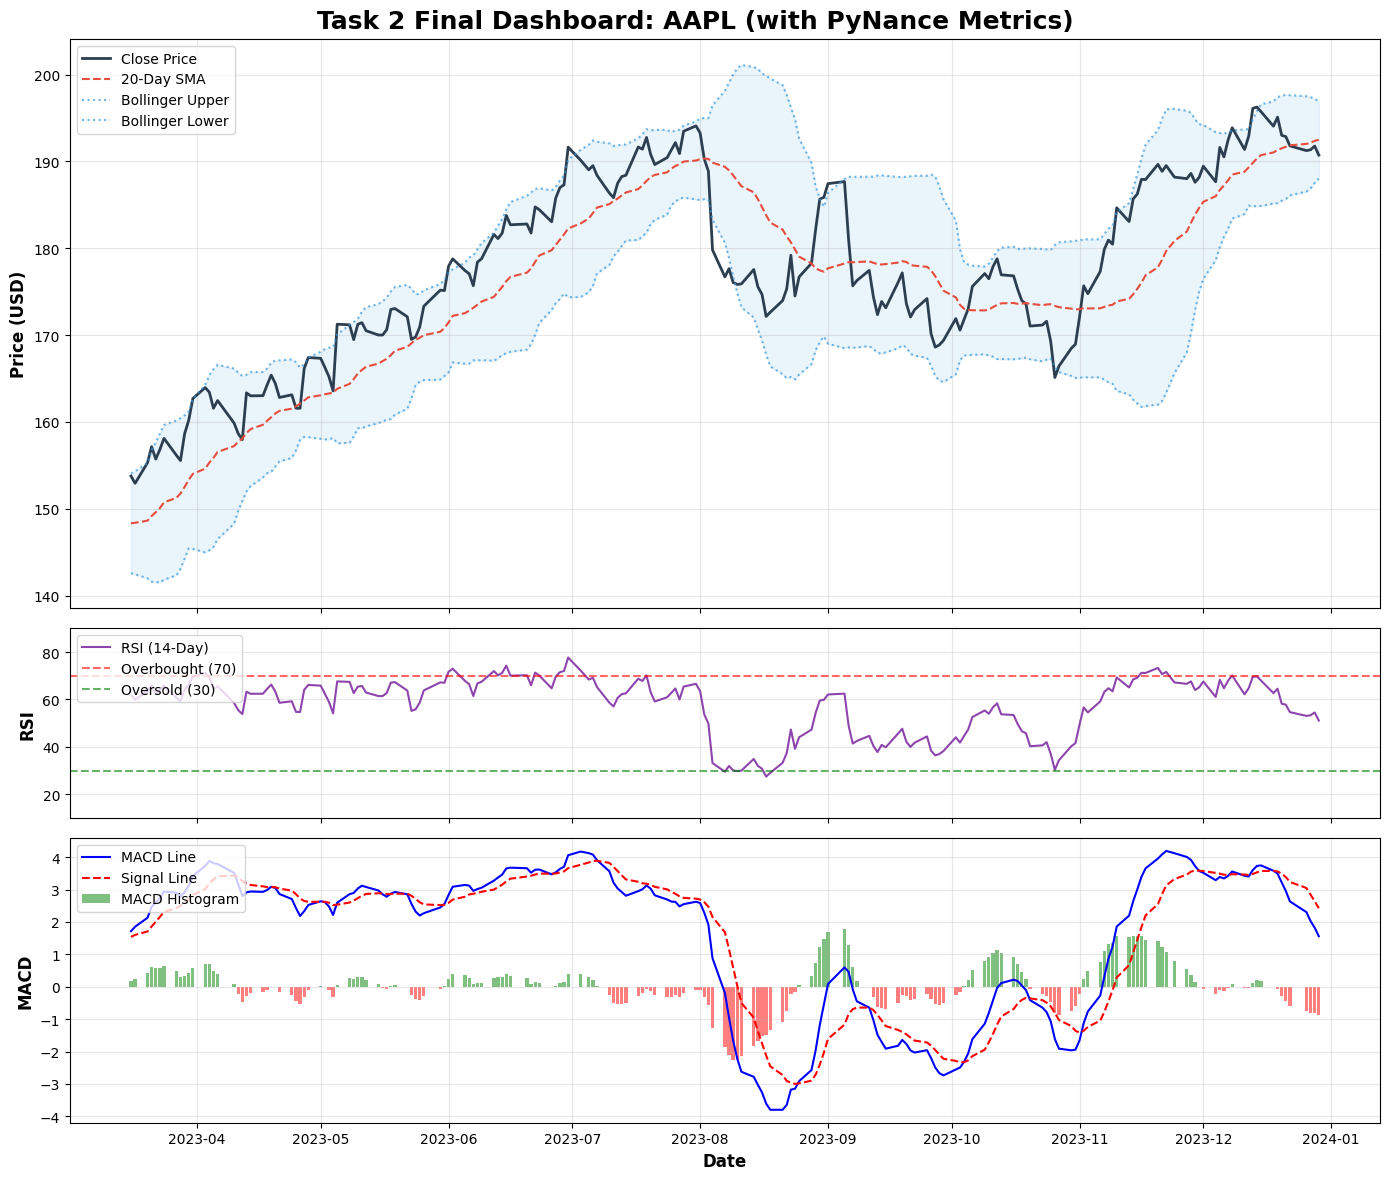

In [ ]:
import matplotlib.pyplot as plt

def plot_final_dashboard(ticker, df):
    plot_df = df.tail(200)
    
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), gridspec_kw={'height_ratios': [3, 1, 1.5]}, sharex=True)
    
    clean_ticker = ticker.split(".")[0]
    fig.suptitle(f'Task 2 Final Dashboard: {clean_ticker} (with PyNance Metrics)', fontsize=18, fontweight='bold')
    
    ax1.plot(plot_df.index, plot_df['Close'], label='Close Price', color='#2c3e50', linewidth=2)
    ax1.plot(plot_df.index, plot_df['SMA_20'], label='20-Day SMA', color='#e74c3c', linestyle='--')
    
    ax1.plot(plot_df.index, plot_df['Bollinger_Upper'], color='#3498db', linestyle=':', alpha=0.7, label='Bollinger Upper')
    ax1.plot(plot_df.index, plot_df['Bollinger_Lower'], color='#3498db', linestyle=':', alpha=0.7, label='Bollinger Lower')
    ax1.fill_between(plot_df.index, plot_df['Bollinger_Lower'], plot_df['Bollinger_Upper'], color='#3498db', alpha=0.1)
    
    ax1.set_ylabel('Price (USD)', fontsize=12, fontweight='bold')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(plot_df.index, plot_df['RSI_14'], label='RSI (14-Day)', color='#8e44ad')
    ax2.axhline(70, color='red', linestyle='--', alpha=0.6, label='Overbought (70)')
    ax2.axhline(30, color='green', linestyle='--', alpha=0.6, label='Oversold (30)')
    ax2.set_ylabel('RSI', fontsize=12, fontweight='bold')
    ax2.set_ylim(10, 90)
    ax2.legend(loc='upper left')
    ax2.grid(True, alpha=0.3)
    
    ax3.plot(plot_df.index, plot_df['MACD'], label='MACD Line', color='blue')
    ax3.plot(plot_df.index, plot_df['MACD_signal'], label='Signal Line', color='red', linestyle='--')
    
    colors = ['green' if val >= 0 else 'red' for val in plot_df['MACD_hist']]
    ax3.bar(plot_df.index, plot_df['MACD_hist'], label='MACD Histogram', color=colors, alpha=0.5)
    
    ax3.set_ylabel('MACD', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Date', fontsize=12, fontweight='bold')
    ax3.legend(loc='upper left')
    ax3.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

aapl_key = 'AAPL.CSV' if 'AAPL.CSV' in stocks_dict else 'AAPL'
if aapl_key in stocks_dict:
    plot_final_dashboard(aapl_key, stocks_dict[aapl_key])
    